In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
decode_lab_internship_w2 = pd.read_excel(
    r"C:\Users\ThePhantomTrader\OneDrive\Desktop\DECODE LABS\Week_2_files\Dataset for Data Analytics.xlsx")
decode_lab_internship_w2

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [3]:
#Undertaking the dataset 
decode_lab_internship_w2.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
decode_lab_internship_w2.shape

(1200, 14)

In [5]:
decode_lab_internship_w2.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

In [6]:
decode_lab_internship_w2.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [7]:
decode_lab_internship_w2.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [8]:
decode_lab_internship_w2.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [9]:
# Summary statistics of the dataset
decode_lab_internship_w2.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [10]:
average_sales = decode_lab_internship_w2["TotalPrice"].mean()
average_sales

np.float64(1053.9683)

In [11]:
max_sale =decode_lab_internship_w2["TotalPrice"].max()
max_sale 

np.float64(3456.4)

In [12]:
min_sale =decode_lab_internship_w2["TotalPrice"].min()
min_sale

np.float64(11.39)

In [13]:
#To find the trends
most_sold_product = decode_lab_internship_w2["Product"].value_counts()
most_sold_product

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [14]:
order_status = decode_lab_internship_w2["OrderStatus"].value_counts()
order_status

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [15]:
payment_method = decode_lab_internship_w2["PaymentMethod"].value_counts()
payment_method

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [16]:
#To find the outliers
Q1 = decode_lab_internship_w2["TotalPrice"].quantile(0.25)
Q3 = decode_lab_internship_w2["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = decode_lab_internship_w2[
    (decode_lab_internship_w2["TotalPrice"] < lower_bound) |
    (decode_lab_internship_w2["TotalPrice"] > upper_bound)
]
outliers

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NaN,Facebook,3384.90
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NaN,Facebook,3390.95


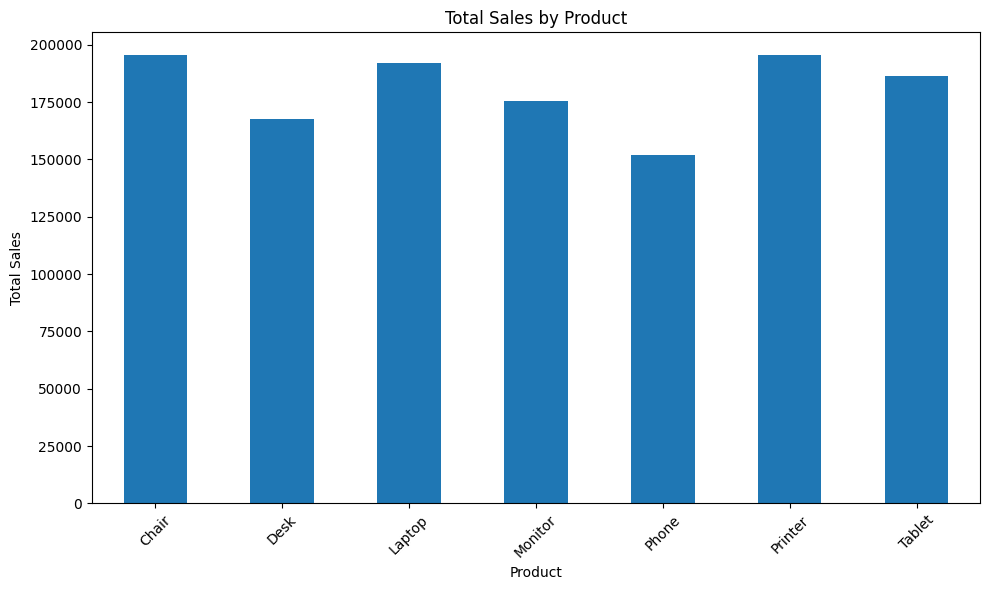

In [17]:
product_sales = decode_lab_internship_w2.groupby("Product")["TotalPrice"].sum()

plt.figure(figsize=(10,6))
product_sales.plot(kind="bar")
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


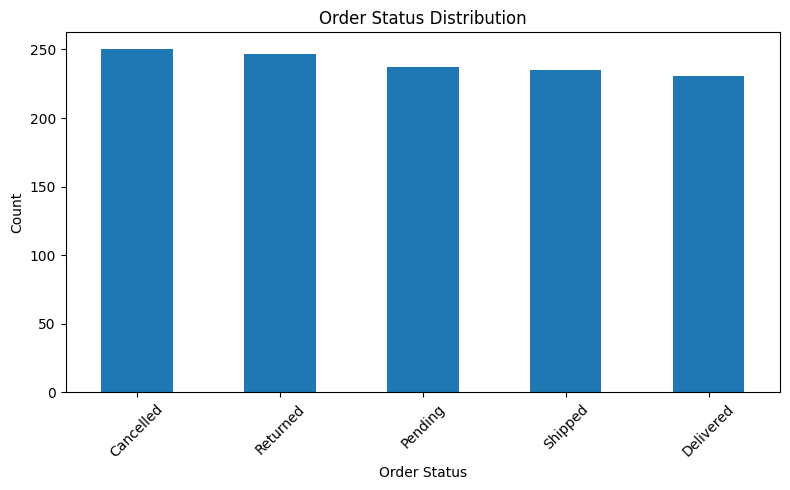

In [18]:
plt.figure(figsize=(8,5))
order_status.plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

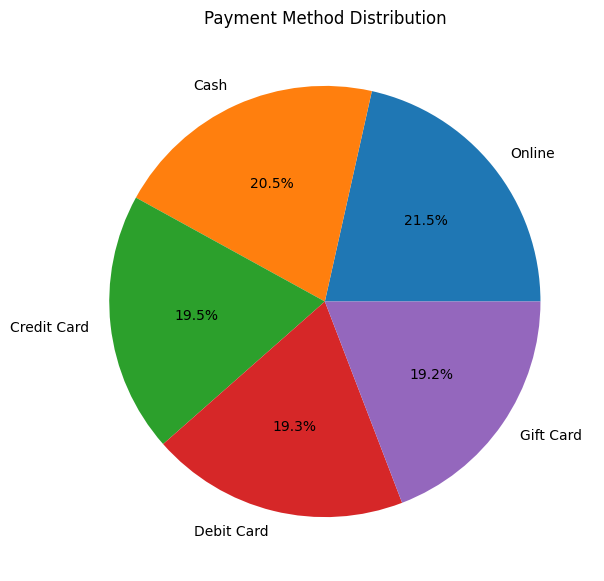

In [19]:
plt.figure(figsize=(7,7))
payment_method.plot(kind="pie", autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

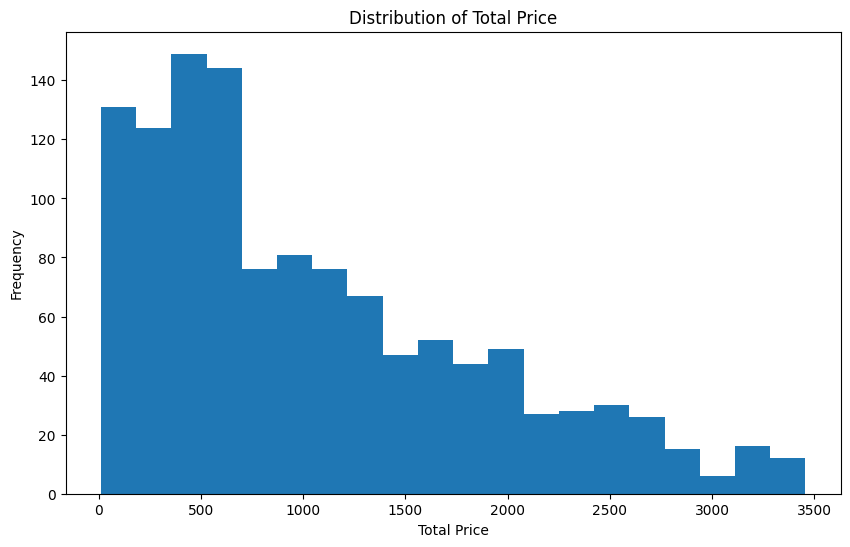

In [20]:
plt.figure(figsize=(10,6))
plt.hist(decode_lab_internship_w2["TotalPrice"], bins=20)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

In [25]:
X = decode_lab_internship_w2[["Quantity", "UnitPrice", "ItemsInCart"]]
y = decode_lab_internship_w2["TotalPrice"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
sample_prediction = model.predict([[5, 500, 3]])

print("MAE:", mae)
print("R2:", r2)

MAE: 211.52582150138193
R2: 0.8904918215121347


C:\Users\ThePhantomTrader\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
